# Wailau Landslide — Dispersive vs. Shallow-Water Tsunami Rays

The **Wailau Landslide** off the north flank of Moloka'i (Hawaiʻi) is one of the largest
submarine landslides on Earth (~1 200 km³), and a benchmark case for short-period tsunami
source physics.  Landslide-generated waves are characteristically **short**, the dominant
wavelength tracks the length scale of the sliding mass, not the ocean basin depth.

Here the slide's characteristic wavelength is taken as **λ = 15 km** (deep-water reference).
At this scale the full linear dispersion relation yields group speeds that are roughly *half*
the shallow-water approximation at typical mid-ocean depths, producing travel-time errors
of > 50 %.  This notebook:

1. Visualises the dispersive group-speed correction as a function of **period** and **wavelength**
   for ocean depths of 500 – 4 000 m.
2. Traces tsunami rays from the Wailau headwall under the **shallow-water** and
   **dispersive** wave speed models and maps the difference in first-arrival times.

> **Requires** `scipy` and `netCDF4`:  `pip install -e ".[examples]"`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import TsunamiTrace as tt

## 1  Dispersion physics

The full linear gravity-wave dispersion relation gives

$$\omega^2 = g\,k\,\tanh(kh)$$

The **group speed** (which carries wave energy, and is the correct quantity for ray theory) is

$$c_{\rm group} = \frac{c_{\rm phase}}{2}\left[1 + \frac{2kh}{\sinh(2kh)}\right], \qquad c_{\rm phase} = \frac{\omega}{k}$$

In the shallow-water limit ($kh \to 0$) this recovers $c_{\rm group} = \sqrt{gh}$.
In the deep-water limit ($kh \to \infty$) it gives $c_{\rm group} = \tfrac{1}{2}\sqrt{g/k}$.

Because $\omega$ is **conserved** along rays, only $k$ (and hence the wave speed) changes
as the wave travels over varying bathymetry.  The helper below solves the dispersion relation
on a grid of depths × frequencies using vectorised Newton–Raphson.

In [2]:
_G = 9.8   # m/s²

def group_speed_grid(depths_1d, omega_1d, n_iter=15):
    """
    Dispersive group speed on a (n_depths × n_omega) grid.

    Parameters
    ----------
    depths_1d : array_like, shape (n_depths,)
    omega_1d  : array_like, shape (n_omega,)

    Returns
    -------
    c_group : ndarray, shape (n_depths, n_omega)
    """
    H     = np.asarray(depths_1d, float)[:, None]   # (n_depths, 1)
    OMEGA = np.asarray(omega_1d,  float)[None, :]   # (1, n_omega)

    k = OMEGA / np.sqrt(_G * H)   # shallow-water initial guess

    for _ in range(n_iter):
        kh      = np.minimum(k * H, 500.0)
        tanh_kh = np.tanh(kh)
        sech2   = np.zeros_like(kh)
        m       = kh < 355.0
        sech2[m] = 1.0 / np.cosh(kh[m]) ** 2
        F  = OMEGA ** 2 - _G * k * tanh_kh
        dF = -_G * (tanh_kh + k * H * sech2)
        k  = np.maximum(k - F / dF, 1e-10)

    kh      = k * H
    c_phase = OMEGA / k
    two_kh  = 2.0 * kh
    ratio   = np.where(two_kh < 1e-6, 1.0,
                       two_kh / np.sinh(np.minimum(two_kh, 500.0)))
    return 0.5 * c_phase * (1.0 + ratio)


DEPTHS = [500, 1000, 2000, 4000]                       # representative depths (m)
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # blue, orange, green, red

# ── Wailau characteristic parameters ─────────────────────────────────────────
LAM_WAILAU   = 15_000                       # deep-water wavelength, m
K_DEEP_W     = 2 * np.pi / LAM_WAILAU      # deep-water wavenumber, rad/m
OMEGA_WAILAU = np.sqrt(_G * K_DEEP_W)      # angular frequency (conserved along rays)
T_WAILAU     = 2 * np.pi / OMEGA_WAILAU    # period, s

print(f"Wailau:  λ_deep = {LAM_WAILAU/1000:.0f} km")
print(f"         ω      = {OMEGA_WAILAU:.5f} rad/s")
print(f"         T      = {T_WAILAU:.1f} s  =  {T_WAILAU/60:.2f} min")

# Group speed at each depth for the Wailau frequency
c_sw_depths = np.array([np.sqrt(_G * h) for h in DEPTHS])
c_g_depths  = group_speed_grid(DEPTHS, [OMEGA_WAILAU])[:, 0]
print()
print(f"{'Depth (m)':>12}  {'c_SW (m/s)':>12}  {'c_group (m/s)':>14}  {'SW error (%)':>13}")
for h, csw, cg in zip(DEPTHS, c_sw_depths, c_g_depths):
    print(f"{h:>12}  {csw:>12.1f}  {cg:>14.1f}  {(csw-cg)/csw*100:>13.1f}")

Wailau:  λ_deep = 15 km
         ω      = 0.06407 rad/s
         T      = 98.1 s  =  1.63 min

   Depth (m)    c_SW (m/s)   c_group (m/s)   SW error (%)
         500          70.0            63.0           10.0
        1000          99.0            80.0           19.2
        2000         140.0            91.2           34.9
        4000         198.0            86.9           56.1


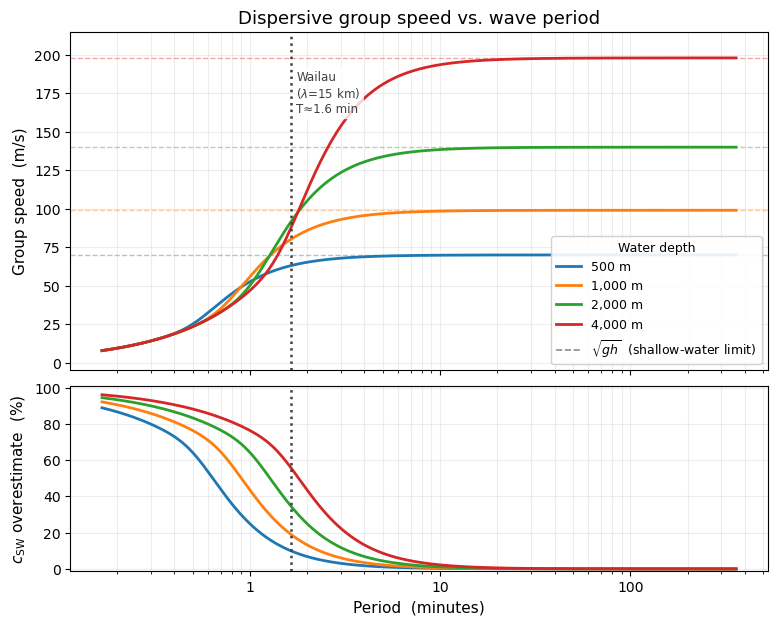

In [3]:
periods  = np.logspace(np.log10(10), np.log10(6 * 3600), 600)   # 10 s → 6 h
omega_T  = 2 * np.pi / periods                                   # (n_periods,)

c_g_T = group_speed_grid(DEPTHS, omega_T)                  # (n_depths, n_periods)
c_sw  = np.array([np.sqrt(_G * h) for h in DEPTHS])        # (n_depths,)

fig, (ax_s, ax_e) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True,
    gridspec_kw={'height_ratios': [2.2, 1.2], 'hspace': 0.06}
)

for i, (h, col) in enumerate(zip(DEPTHS, COLORS)):
    ax_s.plot(periods / 60, c_g_T[i], color=col, lw=2, label=f'{h:,} m')
    ax_s.axhline(c_sw[i], color=col, lw=1, ls='--', alpha=0.4)
    ax_e.plot(periods / 60, (c_sw[i] - c_g_T[i]) / c_sw[i] * 100, color=col, lw=2)

# SW legend dummy entry
ax_s.plot([], [], 'k--', lw=1.2, alpha=0.45, label=r'$\sqrt{gh}$  (shallow-water limit)')

# Wailau vertical marker
for ax in (ax_s, ax_e):
    ax.axvline(T_WAILAU / 60, color='0.25', ls=':', lw=1.8, zorder=4)
ax_s.text(T_WAILAU / 60 * 1.07, 190,
          f'Wailau\n($\lambda$=15 km)\nT≈{T_WAILAU/60:.1f} min',
          fontsize=8.5, va='top', ha='left', color='0.25',
          bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='none'))

ax_s.set_xscale('log')
ax_s.set_ylim(-5, 215)
ax_s.set_ylabel('Group speed  (m/s)', fontsize=11)
ax_s.set_title('Dispersive group speed vs. wave period', fontsize=13)
ax_s.legend(title='Water depth', fontsize=9, title_fontsize=9,
            loc='lower right', framealpha=0.9)
ax_s.grid(True, which='both', alpha=0.22)

ax_e.set_ylim(bottom=-1)
ax_e.set_ylabel(r'$c_{\rm SW}$ overestimate  (%)', fontsize=11)
ax_e.set_xlabel('Period  (minutes)', fontsize=11)
ax_e.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax_e.grid(True, which='both', alpha=0.22)

plt.show()

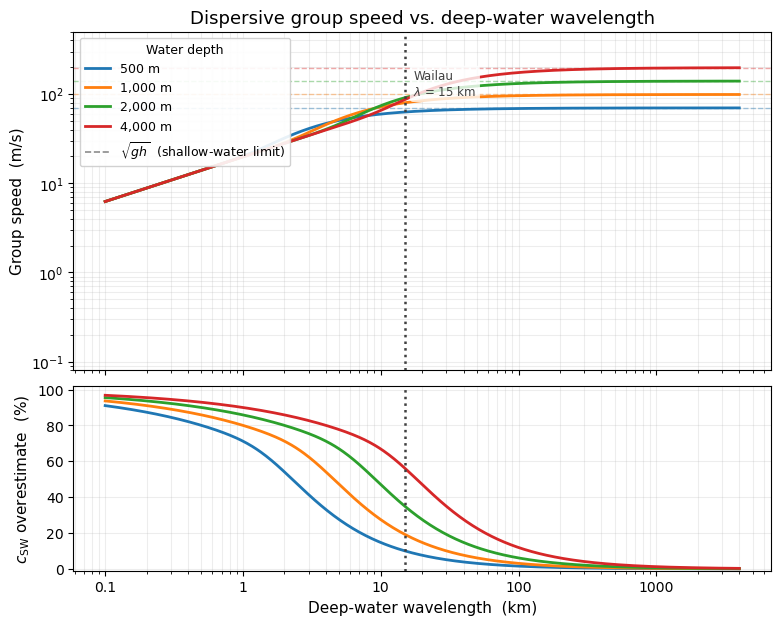

In [4]:
# For the wavelength sweep the user-specified quantity is the deep-water wavelength λ.
# TsunamiTrace converts: k_deep = 2π/λ  →  ω = sqrt(g·k_deep), then conserves ω.
wavelengths = np.logspace(np.log10(100), np.log10(4_000_000), 600)  # 100 m → 4000 km
k_deep_arr  = 2 * np.pi / wavelengths                               # deep-water k
omega_wl    = np.sqrt(_G * k_deep_arr)                              # corresponding ω

c_g_wl = group_speed_grid(DEPTHS, omega_wl)   # (n_depths, n_wavelengths)

fig, (ax_s, ax_e) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True,
    gridspec_kw={'height_ratios': [2.2, 1.2], 'hspace': 0.06}
)

for i, (h, col) in enumerate(zip(DEPTHS, COLORS)):
    ax_s.plot(wavelengths / 1000, c_g_wl[i], color=col, lw=2, label=f'{h:,} m')
    ax_s.axhline(c_sw[i], color=col, lw=1, ls='--', alpha=0.4)
    ax_e.plot(wavelengths / 1000, (c_sw[i] - c_g_wl[i]) / c_sw[i] * 100, color=col, lw=2)

ax_s.plot([], [], 'k--', lw=1.2, alpha=0.45, label=r'$\sqrt{gh}$  (shallow-water limit)')

# Wailau marker at λ = 15 km
for ax in (ax_s, ax_e):
    ax.axvline(LAM_WAILAU / 1000, color='0.25', ls=':', lw=1.8, zorder=4)
ax_s.text(LAM_WAILAU / 1000 * 1.15, 190,
          f'Wailau\n$\lambda$ = {LAM_WAILAU/1000:.0f} km',
          fontsize=8.5, va='top', ha='left', color='0.25',
          bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='none'))

ax_s.set_xscale('log')
ax_s.set_yscale('log')
ax_s.set_ylim(0.08, 500)
ax_s.set_ylabel('Group speed  (m/s)', fontsize=11)
ax_s.set_title('Dispersive group speed vs. deep-water wavelength', fontsize=13)
ax_s.legend(title='Water depth', fontsize=9, title_fontsize=9,
            loc='upper left', framealpha=0.9)
ax_s.grid(True, which='both', alpha=0.22)

ax_e.set_ylim(-1, 102)
ax_e.set_ylabel(r'$c_{\rm SW}$ overestimate  (%)', fontsize=11)
ax_e.set_xlabel('Deep-water wavelength  (km)', fontsize=11)
ax_e.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax_e.grid(True, which='both', alpha=0.22)

plt.show()

## 2  Source and bathymetry

The Wailau slide headwall sits at **21.35°N, 156.85°W**, in approximately
2 600 m of water on the north flank of Moloka'i — solidly in the
intermediate-depth regime for λ = 15 km (kh ≈ 1.1, ~40 % error in the
shallow-water approximation).

We use the full ETOPO2 4 arc-minute NE Pacific grid (−180° to −100°W,
10°N to 65°N) with no domain subsetting, giving basin-scale coverage
from the Hawaiian Ridge to Alaska and the west coast of North America.

In [5]:
# Load the NE-Pacific bathymetry (longitudes stored as 180–260°E; shift to −180–−100°W)
lon_arr, lat_arr, depth = tt.load_bathymetry('../data/NE_pacific_4arcmin.nc')
lon_arr = lon_arr - 360.0

# Use the full NE Pacific grid — no subsetting
lon_sub   = lon_arr
lat_sub   = lat_arr
depth_sub = depth

print(f"Full grid: {depth_sub.shape[0]} lon × {depth_sub.shape[1]} lat cells")
print(f"lon: {lon_sub[0]:.2f}° to {lon_sub[-1]:.2f}°")
print(f"lat: {lat_sub[0]:.2f}° to {lat_sub[-1]:.2f}°")

# ── source: Wailau headwall (north flank of Moloka'i) ─────────────────────────
SRC_LON = -156.85
SRC_LAT =   21.35

il = np.argmin(np.abs(lon_sub - SRC_LON))
jl = np.argmin(np.abs(lat_sub - SRC_LAT))
src_depth = depth_sub[il, jl]
print(f"\nSource location: {SRC_LAT}°N, {abs(SRC_LON):.2f}°W")
print(f"Bathymetry at source: {src_depth:.0f} m")

c_sw_src = np.sqrt(_G * src_depth)
c_g_src  = group_speed_grid([src_depth], [OMEGA_WAILAU])[0, 0]
print(f"  c_SW    = {c_sw_src:.1f} m/s")
print(f"  c_group = {c_g_src:.1f} m/s  (λ = {LAM_WAILAU/1000:.0f} km deep-water)")
print(f"  SW overestimate = {(c_sw_src - c_g_src)/c_sw_src*100:.1f}%")

Full grid: 1200 lon × 825 lat cells
lon: -179.97° to -100.03°
lat: 10.03° to 64.97°

Source location: 21.35°N, 156.85°W
Bathymetry at source: 2591 m
  c_SW    = 159.3 m/s
  c_group = 91.6 m/s  (λ = 15 km deep-water)
  SW overestimate = 42.5%


## 3  Ray tracing

360 rays are fanned from the source at 1° azimuth spacing over the full
NE Pacific basin.  The two runs use different integration windows so that
both wavefronts cover the entire domain:

| Run | dt | max_time | Steps | Why |
|-----|----|----------|-------|-----|
| Shallow-water | 60 s | 12 h | 720 | c ≈ 200 m/s → basin width in ~9.3 h |
| Dispersive    | 120 s | 24 h | 720 | c ≈ 90 m/s → basin width in ~21 h |

- **Shallow-water**: no wave parameter → $c = \sqrt{gh}$ everywhere.
- **Dispersive**: `wavelength=15_000` → $\omega = \sqrt{g\cdot 2\pi/\lambda}$
  conserved along all rays; group speed from the full dispersion relation at each cell.

In [6]:
AZIMUTHS = np.arange(0, 360, 1e-3)

# ── shallow-water: 12 h at 60 s → 720 steps ──────────────────────────────────
DT_SW       = 60
MAX_TIME_SW = 43_200   # 12 h  (c ≈ 200 m/s → crosses the ~6 700 km basin in ~9.3 h)

print("Tracing shallow-water rays …")
ray_lon_sw, ray_lat_sw, _ = tt.trace_rays(
    lon_sub, lat_sub, depth_sub,
    dt=DT_SW, max_time=MAX_TIME_SW,
    source_lon=SRC_LON, source_lat=SRC_LAT,
    azimuths_deg=AZIMUTHS,
)
print(f"  done — shape {ray_lon_sw.shape}")

# ── dispersive: 24 h at 120 s → 720 steps ────────────────────────────────────
DT_DISP       = 120
MAX_TIME_DISP = 86_400   # 24 h  (c ≈ 90 m/s → crosses the basin in ~21 h)

print("Tracing dispersive rays  (λ = 15 km) …")
ray_lon_d, ray_lat_d, _ = tt.trace_rays(
    lon_sub, lat_sub, depth_sub,
    dt=DT_DISP, max_time=MAX_TIME_DISP,
    source_lon=SRC_LON, source_lat=SRC_LAT,
    azimuths_deg=AZIMUTHS,
    wavelength=LAM_WAILAU,
)
print(f"  done — shape {ray_lon_d.shape}")

Tracing shallow-water rays …
  done — shape (360000, 722)
Tracing dispersive rays  (λ = 15 km) …
  done — shape (360000, 722)


In [7]:
BIN_DEG = 0.35   # output resolution

print("Gridding shallow-water travel times …")
lon_bin, lat_bin, tt_sw = tt.grid_travel_times(
    ray_lon_sw, ray_lat_sw, dt=DT_SW,
    lon_arr=lon_sub, lat_arr=lat_sub, depth=depth_sub,
    bin_deg=BIN_DEG, fill=True,
)
print(f"  done — grid {tt_sw.shape}")

print("Gridding dispersive travel times …")
_, _, tt_disp = tt.grid_travel_times(
    ray_lon_d, ray_lat_d, dt=DT_DISP,
    lon_arr=lon_sub, lat_arr=lat_sub, depth=depth_sub,
    bin_deg=BIN_DEG, fill=True,
)
print(f"  done — grid {tt_disp.shape}")

# Both maps are in hours; compute the delay (dispersive arrives later → positive)
tt_diff = tt_disp - tt_sw   # hours

print(f"\nMax SW travel time        : {np.nanmax(tt_sw):.1f} h")
print(f"Max dispersive travel time : {np.nanmax(tt_disp):.1f} h")
print(f"Max delay (disp − SW)      : {np.nanmax(tt_diff):.1f} h")

Gridding shallow-water travel times …
  done — grid (158, 230)
Gridding dispersive travel times …
  done — grid (158, 230)

Max SW travel time        : 12.0 h
Max dispersive travel time : 24.0 h
Max delay (disp − SW)      : 22.9 h


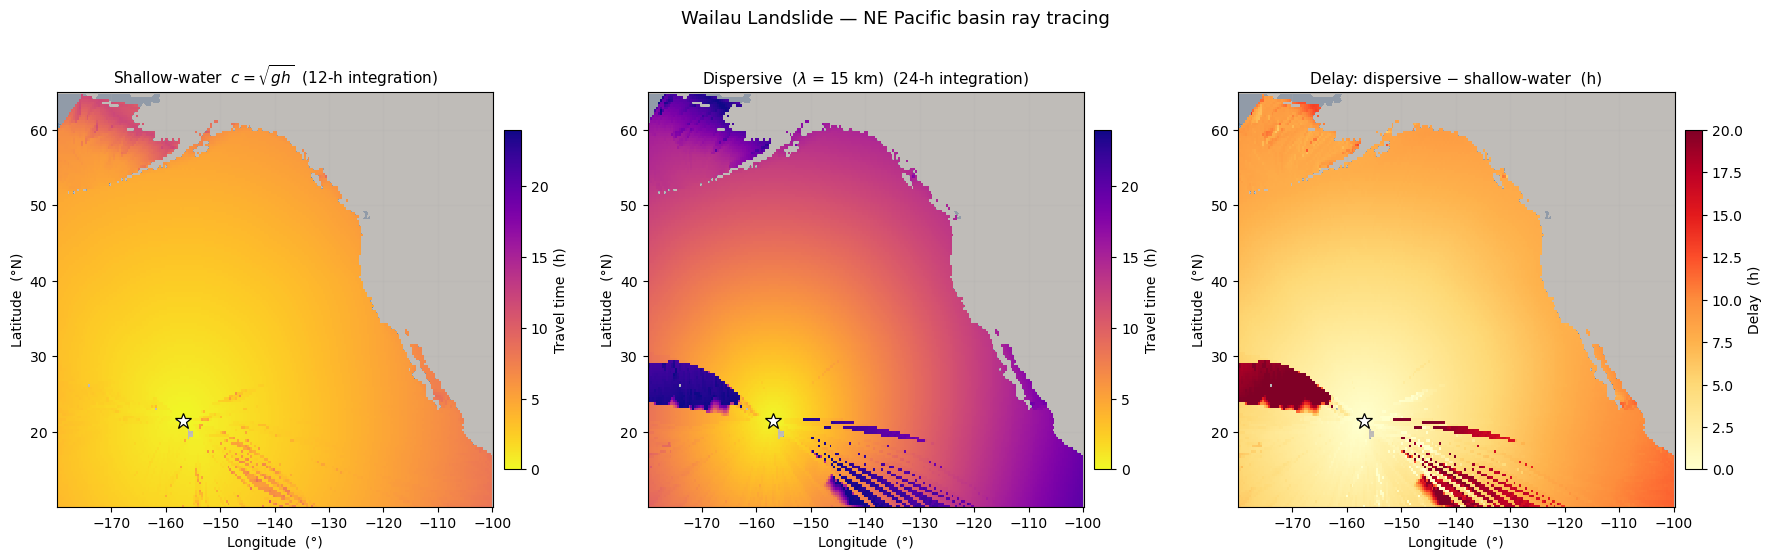

In [8]:
# ── ocean/land mask at bin resolution ────────────────────────────────────────
from scipy.interpolate import RegularGridInterpolator
rgi = RegularGridInterpolator((lon_sub, lat_sub), depth_sub,
                               method='linear', bounds_error=False, fill_value=0.0)
LON_B, LAT_B = np.meshgrid(lon_bin, lat_bin)
depth_bin    = rgi((LON_B, LAT_B))
ocean_depth  = np.where(depth_bin > 0, depth_bin, np.nan)

# ── colour scales (travel time in hours) ──────────────────────────────────────
# Use the same 0–24 h scale for both travel-time panels so wavefront positions
# are directly comparable; dispersive contours sit at roughly twice the hours
# of their shallow-water counterparts.
vmax_tt   = 24.0   # h
vmax_diff = max(float(np.nanpercentile(tt_diff, 98)), 0.1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

TT_MAPS = [tt_sw, tt_disp, tt_diff]
CMAPS   = ['plasma_r', 'plasma_r', 'YlOrRd']
VMAXS   = [vmax_tt, vmax_tt, vmax_diff]
LABELS  = ['Travel time  (h)', 'Travel time  (h)', 'Delay  (h)']
TITLES  = [
    r'Shallow-water  $c = \sqrt{gh}$  (12-h integration)',
    f'Dispersive  ($\lambda$ = {LAM_WAILAU/1000:.0f} km)  (24-h integration)',
    'Delay: dispersive − shallow-water  (h)',
]

for ax, tt_map, cmap, vmax, title, label in zip(
        axes, TT_MAPS, CMAPS, VMAXS, TITLES, LABELS):

    ax.set_facecolor('#bfbcb8')

    ax.contourf(lon_bin, lat_bin, ocean_depth,
                levels=np.linspace(0, 6000, 13), cmap='Blues_r',
                alpha=0.25, zorder=1)

    pcm = ax.pcolormesh(lon_bin, lat_bin, tt_map,
                        cmap=cmap, vmin=0, vmax=vmax,
                        shading='nearest', zorder=2)
    fig.colorbar(pcm, ax=ax, label=label, pad=0.02, shrink=0.82)

    ax.plot(SRC_LON, SRC_LAT, '*', ms=12, color='white',
            mec='black', mew=0.9, zorder=6)

    ax.set_xlim(lon_bin[0], lon_bin[-1])
    ax.set_ylim(lat_bin[0], lat_bin[-1])
    ax.set_xlabel('Longitude  (°)', fontsize=10)
    ax.set_ylabel('Latitude  (°N)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.18)

plt.suptitle("Wailau Landslide — NE Pacific basin ray tracing", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()